# DL Astronomy

## Imports

In [50]:
import os

import kagglehub
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## Dataset loading

In [ ]:
path = kagglehub.dataset_download("anjosut/galaxy-zoo-classification")

## EDA

### Dataset analysis

In [52]:
data_dir = Path(os.path.join(path, "Train_images", "Train_images"))

valid_classes = [
    "Cigar-shaped smooth", 
    "completely round smooth", 
    "edge-on", 
    "In between smooth", 
    "spiral"
]

class_counts = {}

for i, class_name in enumerate(valid_classes):
    class_path = data_dir / class_name
    image_files = list(class_path.glob('*.jpg'))
    class_counts[class_name] = len(image_files)

print(f"Total images: {sum(class_counts.values())}")

Total images: 28793


### Target distribution

                     class  count
0      Cigar-shaped smooth    579
1  completely round smooth   8436
2                  edge-on   3903
3        In between smooth   8069
4                   spiral   7806


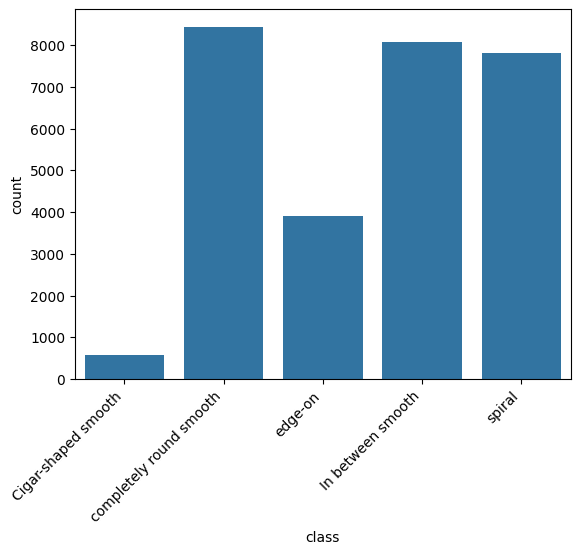

In [58]:

df = pd.DataFrame(list(class_counts.items()), columns=["class", "count"])
print(df)

sns.barplot(data=df, x="class", y="count")
plt.xticks(rotation=45, ha="right")
plt.show()


### Sample images

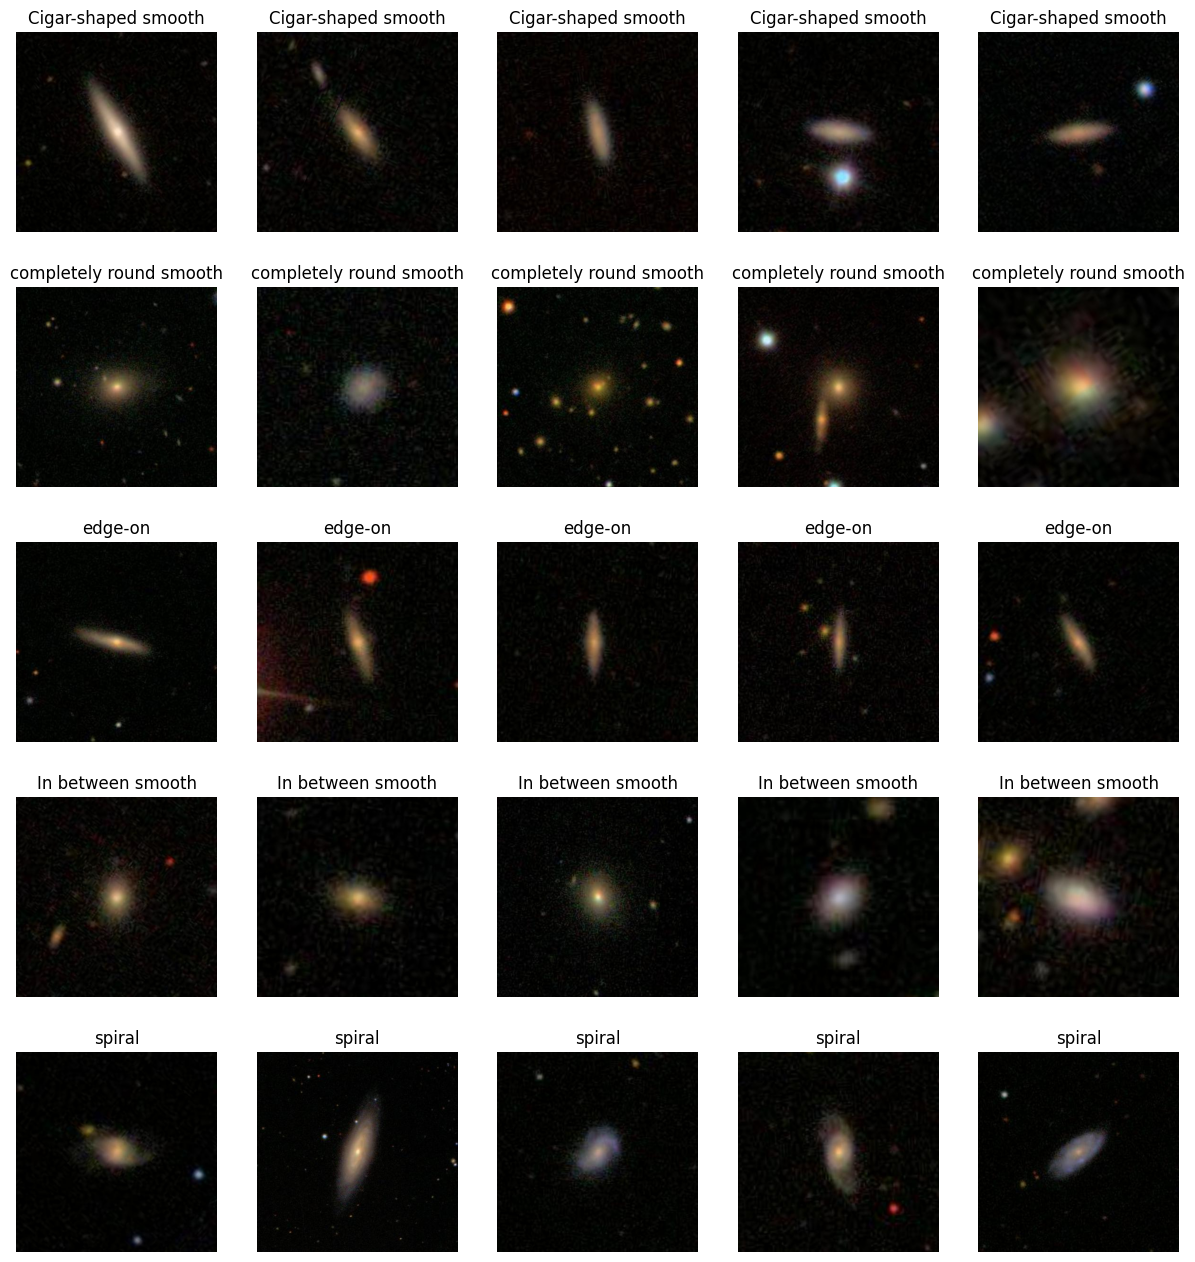

In [61]:
fig, axes = plt.subplots(len(valid_classes), 5, figsize=(15, 16))

for i, class_name in enumerate(valid_classes):
    class_path = data_dir / class_name
    image_files = list(class_path.glob('*.jpg'))[:5]
    
    for j, img_path in enumerate(image_files):
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        axes[i, j].set_title(f"{class_name}")
        if j == 0:
            axes[i, j].set_ylabel(class_name.upper(), fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')